In [3]:
%reload_ext autoreload
%autoreload 2

In [6]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from typing import List, Dict
import torch
from matplotlib.patches import Patch



# ST eval

Loading and preparing data...
Creating base plot...
Applying visual styling...
Creating custom legend...
Plot created successfully!


/tmp/ipykernel_882199/3681515810.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data["metric"] = plot_data["metric"].map(metric_mapping).fillna(plot_data["metric"])


Plot saved with transparent background to: sentence_transformer.png


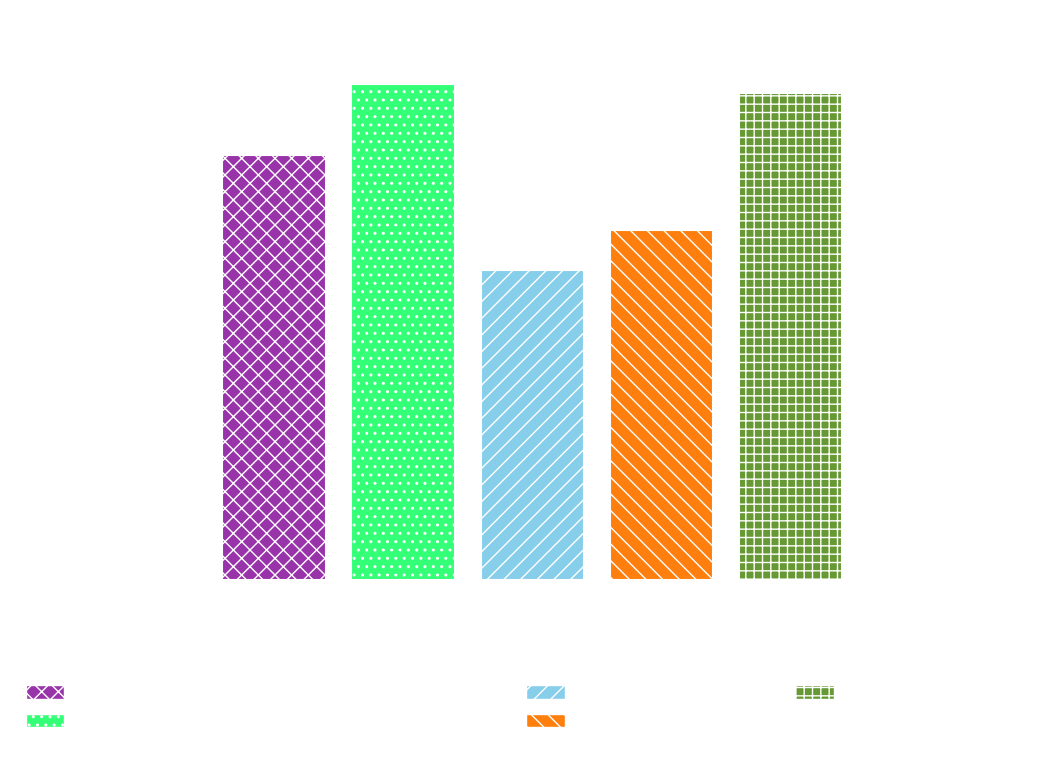

In [ ]:
dataset_name = "NASA-SDE IR"
desired_metric_types = ["mrr"]
json_output_path = "/rhome/sawale/indus_traning/sentense_transformers/eval/results_json/nasa_sde_ir_v3_eval_dump.json"

models = {
    "modernbert-embed-base": {
        "path": "nomic-ai/modernbert-embed-base",
        "color": "#87CEEB",
        "hatch": "//",  # Diagonal lines
        "model_config": {
            "torch_dtype": torch.float16,
        },
        "display_name": "ModernBERT",
    },
    "nasa-smd-ibm-st-v2": {
        "path": "nasa-impact/nasa-smd-ibm-st-v2",
        "color": "#ff7f0e",
        "hatch": "\\\\",  # Reverse diagonal lines
        "display_name": "Original INDUS-ST",
    },
    "indus-sde-st-v0.2_polar-monkey-61_30k": {
        "path": "/rhome/sawale/indus_traning/sentense_transformers/eval/artifacts/model-6hjbp1bx:v1/checkpoint-30000",
        "color": "#33ff77",
        "hatch": "..",  # Dots
        "display_name": "INDUS-SDE-ST",
    },
    "indus-sde-st-v0.2-61_30k-ubinary_emb": {
        "path": "/rhome/sawale/indus_traning/sentense_transformers/eval/artifacts/model-6hjbp1bx:v1/checkpoint-30000",
        "color": "#9933aa",
        "hatch": "xx",
        "similarity_fn_name": "hamming",
        "display_name": "INDUS-SDE-ST-Post-Inference-Binarization",
    },
    "s2_ruby-water-86": {
        "path": "/rhome/sawale/indus_traning/sentense_transformers/eval/artifacts/s2_binarized_model/ruby-water-86/checkpoint-20000",
        "color": "#669933",
        "hatch": "++",
        "similarity_fn_name": "hamming",
        "display_name": "INDUS-SDE-ST-QAT",
    }
}

embeddings = {
}

metric_mapping = {
    "mrr": "Mean Reciprocal Rank (MRR)"
}

def convert_json_output_to_df(json_output_path):
    if not os.path.exists(json_output_path):
        print(
            f"JSON output path {json_output_path} does not exist."
            "Please run the evaluation first.",
        )
        return
    with open(json_output_path, "r", encoding="utf-8") as f:
        all_results = json.load(f)

    # lets make a df first of the json
    records = []
    for model, metrics in all_results.items():
        for metric_name_full, value in metrics.items():
            parts = metric_name_full.split("__")
            dataset_name_str = parts[0]
            subset_str = parts[1]
            data_file_str = parts[2]
            remaining_str = parts[-1]

            parts = remaining_str.split("@")
            k = int(parts[1])
            metric_name = parts[0].split("_")[-1]
            records.append(
                {
                    "dataset_name": dataset_name_str,
                    "subset": subset_str,
                    "data_file": data_file_str,
                    "model": model,
                    "metric": metric_name,
                    "k": k,
                    "value": value,
                },
            )

    # Create a pandas DataFrame
    df = pd.DataFrame(records)

    return df


def plot_results(
    json_output_path, 
    top_k=5,  # Changed from top_ks list to single value
    dpi=600, 
    legend_cols=2,
    model_name_mapper=None,
    subset="",
    data_file="weightedmean",
    save_path=None,
    figsize=(12,8)
):
    """
    Create beautiful bar chart for model performance metrics.
    
    Args:
        json_output_path (str): Path to JSON results file
        top_k (int): K value to include in plot (single value instead of list)
        dpi (int): Plot resolution
        legend_cols (int): Number of legend columns
        model_name_mapper (dict): Map internal names to display names
        subset (str): Data subset to filter
        data_file (str): Specific data file to plot
        save_path (str): Path to save the plot
    """
    
    # ===== 1. DATA PREPARATION =====
    print("Loading and preparing data...")
    df = convert_json_output_to_df(json_output_path)
    df = df[df["metric"].isin(desired_metric_types)]
    df = df[df["k"] == top_k]  # Filter for single K value
    
    if df.empty:
        print(f"No data found for K value: {top_k}")
        return
    
    # Filter data
    subset_df = df[df["subset"] == subset]
    plot_data = subset_df[subset_df["data_file"] == data_file]
    
    if plot_data.empty:
        print(f"No data found for subset '{subset}' and data_file '{data_file}'")
        return

    # Map metric names
    plot_data["metric"] = plot_data["metric"].map(metric_mapping).fillna(plot_data["metric"])
    
    # ===== 2. STYLING CONFIGURATION =====
    all_model_configs = {**models, **embeddings}
    model_color_palette = {
        name: config["color"] for name, config in all_model_configs.items()
    }
    model_hatch_palette = {
        name: config.get("hatch", None) for name, config in all_model_configs.items()
    }
    
    # Get models present in data
    present_models = set(plot_data["model"].unique())
    sorted_model_names = sorted([m for m in all_model_configs.keys() if m in present_models])
    
    # ===== 3. PLOT CREATION =====
    print("Creating base plot...")
    
    # Set DARK THEME style to match GKR plot
    sns.set_style("darkgrid", {
        'grid.alpha': 0.4,
        'axes.facecolor': 'none',
        'figure.facecolor': 'none'
    })
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelsize': 16,
        'axes.titlesize': 18,
        'legend.fontsize': 14,
        'figure.titlesize': 20,
        'text.color': 'white',
        'axes.labelcolor': 'white',
        'xtick.color': 'white',
        'ytick.color': 'white',
        'axes.edgecolor': 'white',
        'grid.color': 'white',
    })
    
    # Create single plot (no subplots)
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create bar plot
    bars = ax.bar(
        range(len(sorted_model_names)), 
        [plot_data[plot_data['model'] == model]['value'].iloc[0] for model in sorted_model_names],
        color=[model_color_palette.get(model, '#888888') for model in sorted_model_names],
        edgecolor='white',
        linewidth=1.5
    )
    
    # ===== 4. APPLY HATCH PATTERNS =====
    print("Applying visual styling...")
    for i, model_name in enumerate(sorted_model_names):
        hatch_pattern = model_hatch_palette.get(model_name)
        if hatch_pattern:
            bars[i].set_hatch(hatch_pattern)
            bars[i].set_edgecolor('white')
            bars[i].set_linewidth(1.5)
    
    # ===== 5. AXES FORMATTING =====
    # Match GKR plot styling
    ax.patch.set_facecolor('none')
    ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='white')
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
    ax.tick_params(axis='both', which='major', labelsize=14, colors='white', labelcolor='white')
    
    # Enhanced spine styling to match GKR plot
    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_linewidth(1.0)
    
    # Set labels and title
    ax.set_xlabel('Models', fontsize=16, color='white', fontweight='bold')
    ax.set_ylabel('Mean Reciprocal Rank (MRR)', fontsize=16, color='white', fontweight='bold')
    
    # Set x-axis labels
    display_names = [model_name_mapper.get(model, model) if model_name_mapper else model 
                    for model in sorted_model_names]
    # ax.set_xticks(range(len(sorted_model_names)))
    # ax.set_xticklabels(display_names, rotation=45, ha='right')

    ax.set_xticks([])
    ax.set_xticklabels([])
    
    # ===== 6. VALUE ANNOTATIONS =====
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.3f}", 
                (bar.get_x() + bar.get_width() / 2, height), 
                ha="center", 
                va="bottom", 
                xytext=(0, 5),
                textcoords="offset points", 
                fontsize=12,
                fontweight='bold',
                color='white'
            )
    
    # ===== 7. CUSTOM LEGEND =====
    print("Creating custom legend...")
    legend_handles = []
    for model_name in sorted_model_names:
        display_label = (model_name_mapper.get(model_name, model_name) 
                        if model_name_mapper else model_name)
        
        handle = Patch(
            facecolor=model_color_palette.get(model_name, '#888888'),
            hatch=model_hatch_palette.get(model_name),
            label=display_label,
            edgecolor='white',
            linewidth=1.0
        )
        legend_handles.append(handle)
    
    # Create legend with GKR-style positioning
    legend = ax.legend(
        handles=legend_handles,
        loc="upper center",       
        bbox_to_anchor=(0.5, -0.15),  # Position below plot
        ncol=min(legend_cols, len(legend_handles)),
        frameon=True,
        fancybox=True,
        shadow=False,
        fontsize=14,
        columnspacing=1.8,
        handletextpad=1.0,
        borderpad=0.8
    )
    
    # Style legend frame to match GKR plot
    legend.get_frame().set_facecolor('none')
    legend.get_frame().set_edgecolor('white')
    legend.get_frame().set_linewidth(1.0)
    
    for text in legend.get_texts():
        text.set_color('white')
    
    # ===== 8. TITLE =====
    title = f"Model Performance on {dataset_name} Benchmark (K={top_k})"
    if subset and subset not in ["", "None"]: 
        title += f" - {subset}"
    if data_file and data_file != "weightedmean":
        title += f" - {data_file.split('/')[-1]}"
    
    ax.set_title(
        title, 
        fontsize=20, 
        fontweight='bold',
        color='white',
        pad=20
    )
    
    # ===== 9. FINAL TOUCHES =====
    fig.patch.set_facecolor('none')  # Transparent background
    plt.tight_layout()
    
    print("Plot created successfully!")
    
    # ===== 10. SAVE WITH TRANSPARENT BACKGROUND =====
    if save_path:
        fig.savefig(
            save_path, 
            dpi=dpi, 
            bbox_inches='tight', 
            facecolor='none',
            edgecolor='none',
            transparent=True,
            pad_inches=0.1
        )
        print(f"Plot saved with transparent background to: {save_path}")
    
    return fig

# ===== UPDATED USAGE =====
model_name_mapper = {
    model_name: model_info["display_name"]
    for model_name, model_info in models.items()
    if "display_name" in model_info
}

# Create and save plot with single K value
fig = plot_results(
    json_output_path, 
    model_name_mapper=model_name_mapper,
    top_k=5,  # Single K value instead of list
    legend_cols=3,
    save_path="sentence_transformer.png",
    figsize=(10,8),
)

plt.show()

# For GKR

In [7]:
gkr_df = pd.read_parquet("/rhome/sawale/indus_traning/mlm-fine-tuning/downstream_unification/evaluators/metrics_comparision_with_splits/k/k_all_metrics.parquet")
gkr_df.head()

,k,weighted_precision,weighted_recall,weighted_f1,weighted_jaccard_similarity,haystack_document_recall,haystack_document_mrr,haystack_document_ndcg,haystack_document_map,model,data_split
0,1,0.413576,0.132992,0.175685,0.121089,0.709626,0.709626,0.325992,0.709626,nasa-smd-ibm-v0.1,test
1,2,0.458938,0.236148,0.275617,0.200643,0.793935,0.751780,0.457581,0.751780,nasa-smd-ibm-v0.1,test
2,3,0.471672,0.321092,0.347749,0.257887,0.833908,0.765105,0.535191,0.759112,nasa-smd-ibm-v0.1,test
3,4,0.468873,0.396392,0.401670,0.302562,0.862623,0.772283,0.592198,0.758602,nasa-smd-ibm-v0.1,test
4,5,0.451905,0.445215,0.423276,0.319339,0.879853,0.775729,0.620877,0.755034,nasa-smd-ibm-v0.1,test


In [8]:
gkr_df["model"].unique()

array(['nasa-smd-ibm-v0.1', 'modernbert-sde-v0.2', 'indus-sde-v0.2'],
      dtype=object)

Line plot saved with transparent background to: gkr_mrr_line_comparison.png
Model configurations used:
  Original INDUS-ST-GKR: {'color': '#ff7f0e', 'marker': 'o', 'linestyle': '-', 'markersize': 8}
  ModernBERT-SDE-GKR: {'color': '#87CEEB', 'marker': 's', 'linestyle': '--', 'markersize': 8}
  INDUS-SDE-GKR: {'color': '#33ff77', 'marker': '^', 'linestyle': '-.', 'markersize': 9}


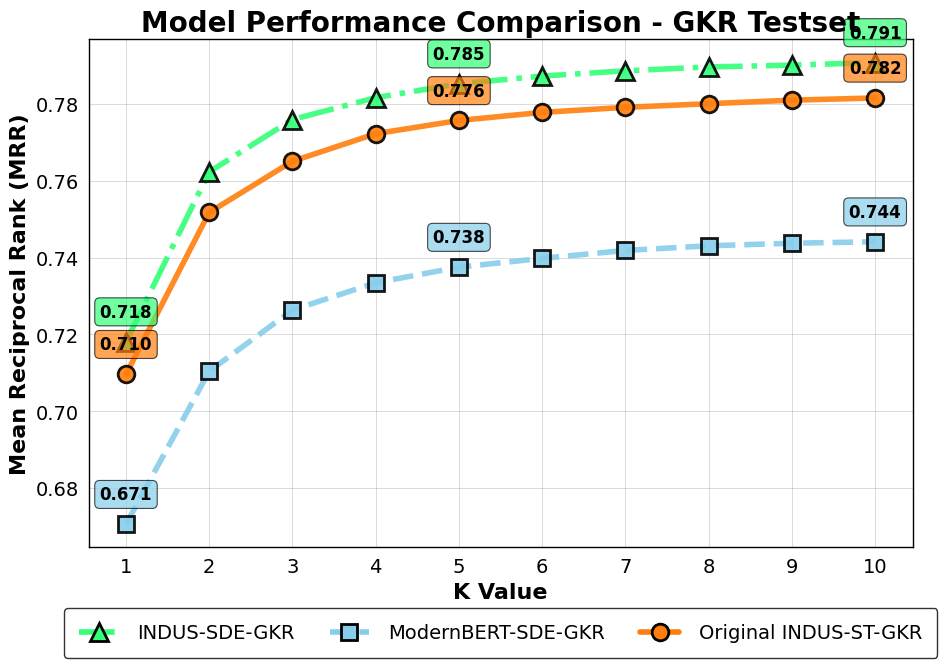

In [10]:
def plot_mrr_line_comparison(
    gkr_df,
    model_config,  # Now accepts model_config as parameter
    model_name_mapping=None,
    topks=None,
    save_path=None,
    dpi=600,
    legend_cols=3,
    figsize=(12,8),
    annotation_k_values=[1,5,10]
):
    """
    Create MRR line plot comparison with different markers and line styles
    
    Args:
        gkr_df: DataFrame with columns ['k', 'haystack_document_mrr', 'model']
        model_config: Dictionary with model configurations (colors, markers, line styles)
        model_name_mapping: Dictionary to map model names to display names
        topks: List of k values to include
        save_path: Path to save the plot
        dpi: Plot resolution
        legend_cols: Number of legend columns
        annotation_k_values: List of K values to annotate (to reduce crowding)
    
    Returns:
        tuple: (figure, model_configs_used)
    """
    
    # Apply model name mapping if provided
    if model_name_mapping:
        gkr_df["model"] = gkr_df["model"].map(model_name_mapping).fillna(gkr_df["model"])
    
    # Filter for specified top-k values if provided
    if topks:
        gkr_df = gkr_df[gkr_df["k"].isin(topks)]
    
    # Extract display names and create model_configs for plotting
    model_configs = {}
    for model_key, config in model_config.items():
        display_name = config.get("display_name", model_key)
        model_configs[display_name] = {
            "color": config["color"],
            "marker": config["marker"], 
            "linestyle": config["linestyle"],
            "markersize": config["markersize"]
        }
    
    # Get models present in data
    present_models = set(gkr_df["model"].unique())
    sorted_model_names = sorted([m for m in model_configs.keys() if m in present_models])
    
    # Set dark theme style
    sns.set_style("darkgrid", {
        'grid.alpha': 0.3,
        'axes.facecolor': 'none',
        'figure.facecolor': 'none'
    })
    
    # plt.rcParams.update({
    #     'font.size': 16,
    #     'axes.labelsize': 16,
    #     'axes.titlesize': 18,
    #     'legend.fontsize': 14,
    #     'figure.titlesize': 20,
    #     'text.color': 'white',
    #     'axes.labelcolor': 'white',
    #     'xtick.color': 'white',
    #     'ytick.color': 'white',
    #     'axes.edgecolor': 'white',
    #     'grid.color': 'white',
    # })
    plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'figure.titlesize': 20,
    'text.color': 'black',        # Changed from 'white' to 'black'
    'axes.labelcolor': 'black',   # Changed from 'white' to 'black'
    'xtick.color': 'black',       # Changed from 'white' to 'black'
    'ytick.color': 'black',       # Changed from 'white' to 'black'
    'axes.edgecolor': 'black',    # Changed from 'white' to 'black'
    'grid.color': 'gray',         # Changed from 'white' to 'gray'
})
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create line plots for each model
    for model in sorted_model_names:
        model_data = gkr_df[gkr_df['model'] == model].sort_values('k')
        config = model_configs[model]
        
        # Plot line with markers - THICKER LINES AND BIGGER MARKERS
        line = ax.plot(
            model_data['k'], 
            model_data['haystack_document_mrr'],
            color=config['color'],
            marker=config['marker'],
            linestyle=config['linestyle'],
            linewidth=4.0,  # Thick lines
            markersize=config['markersize'] + 4,  # Bigger markers (+4 to your original sizes)
            # markeredgecolor='white',
            markeredgecolor='black',

            markeredgewidth=2.0,  # Thick marker edges
            label=model,
            alpha=0.9
        )[0]
        
        # Add value annotations at selected points only
        for k, mrr in zip(model_data['k'], model_data['haystack_document_mrr']):
            if k in annotation_k_values:  # Only annotate specific K values
                ax.annotate(
                    f"{mrr:.3f}",
                    (k, mrr),
                    xytext=(0, 15),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=12,
                    # color='white',
                    color='black',
                    fontweight='bold',
                    bbox=dict(
                        boxstyle='round,pad=0.3',
                        facecolor=config['color'],
                        alpha=0.7,
                        # edgecolor='white',
                        edgecolor='black',
                        
                        linewidth=0.8
                    )
                )
    
    # Customize axes
    # ax.set_xlabel('K Value', fontsize=16, color='white', fontweight='bold')
    # ax.set_ylabel('Mean Reciprocal Rank (MRR)', fontsize=16, color='white', fontweight='bold')
    # ax.set_title('Model Performance Comparison - GKR Testset', fontsize=20, color='white', fontweight='bold')
    ax.set_xlabel('K Value', fontsize=16, color='black', fontweight='bold')
    ax.set_ylabel('Mean Reciprocal Rank (MRR)', fontsize=16, color='black', fontweight='bold')
    ax.set_title('Model Performance Comparison - GKR Testset', fontsize=20, color='black', fontweight='bold')
    # Style axes
    ax.patch.set_facecolor('none')
    # ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='white')
    ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='gray')
    
    ax.set_axisbelow(True)
    # ax.tick_params(axis='both', which='major', labelsize=14, colors='white', labelcolor='white')
    ax.tick_params(axis='both', which='major', labelsize=14, colors='black', labelcolor='black')
    
    for spine in ax.spines.values():
        # spine.set_color('white')
        spine.set_color('black')

        spine.set_linewidth(1.0)
    
    # Set x-axis to show all k values
    ax.set_xticks(sorted(gkr_df['k'].unique()))
    
    # Create custom legend
    legend_handles = []
    for model_name in sorted_model_names:
        config = model_configs[model_name]
        # Create a line handle for the legend - MATCH THICK LINES
        from matplotlib.lines import Line2D
        handle = Line2D(
            [0], [0],
            color=config['color'],
            marker=config['marker'],
            linestyle=config['linestyle'],
            linewidth=4.0,  # Match thick lines
            markersize=config['markersize'] + 4,  # Match bigger markers
            # markeredgecolor='white',
            markeredgecolor='black',

            markeredgewidth=2.0,  # Match thick edges
            label=model_name
        )
        legend_handles.append(handle)
    
    legend = ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=legend_cols,
        frameon=True,
        fancybox=True,
        shadow=False,
        fontsize=14,
        columnspacing=1.8,
        handletextpad=1.0,
        borderpad=0.8
    )
    
    # Style legend for dark theme
    legend.get_frame().set_facecolor('none')
    # legend.get_frame().set_edgecolor('white')
    legend.get_frame().set_edgecolor('black')

    legend.get_frame().set_linewidth(1.0)
    
    for text in legend.get_texts():
        # text.set_color('white')
        text.set_color('black')

    
    # Set figure background
    fig.patch.set_facecolor('none')
    
    plt.tight_layout()
    
    # Save with transparent background if path provided
    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight',
            facecolor='none',
            edgecolor='none',
            transparent=True,
            pad_inches=0.1
        )
        print(f"Line plot saved with transparent background to: {save_path}")
    
    return fig, model_configs

# ===== USAGE WITH YOUR model_config =====

# Your model configuration
model_config = {
    'nasa-smd-ibm-v0.1': {
        "display_name": "Original INDUS-ST-GKR",
        "color": "#ff7f0e", 
        "marker": "o", 
        "linestyle": "-",
        "markersize": 8
        },
    "modernbert-sde-v0.2": {
        "display_name": "ModernBERT-SDE-GKR",
        "color": "#87CEEB", 
        "marker": "s", 
        "linestyle": "--",
        "markersize": 8
        },
    "indus-sde-v0.2": {
        "display_name": "INDUS-SDE-GKR",
        "color": "#33ff77", 
        "marker": "^", 
        "linestyle": "-.",
        "markersize": 9
        },
}

# Model name mapping
model_name_mapping = {
    'nasa-smd-ibm-v0.1': "Original INDUS-ST-GKR",
    "modernbert-sde-v0.2": "ModernBERT-SDE-GKR",
    "indus-sde-v0.2": "INDUS-SDE-GKR",
}

# K values to include and annotate
topks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
annotation_k_values = [1, 5, 10]

# Create the line plot using your model_config
fig, model_configs_used = plot_mrr_line_comparison(
    gkr_df=gkr_df,
    model_config=model_config,  # Pass your model_config here
    model_name_mapping=model_name_mapping,
    topks=topks,
    save_path="gkr_mrr_line_comparison.png",
    legend_cols=3,
    figsize=(10,7),
    annotation_k_values=annotation_k_values
)

# Print the model configurations that were used
print("Model configurations used:")
for model, config in model_configs_used.items():
    print(f"  {model}: {config}")

plt.show()

# for masking accuray

In [13]:
masking_accuracies = {
    "Original INDUS": {
        "data": {
                "top1": 0.503,
                "top2": 0.585,
                "top3": 0.622
            }
    },
    "INDUS-SDE": {
        "data": {
                "top1": 0.781,
                "top2": 0.832,
                "top3": 0.855
            }
    },
    "ModernBERT-SDE": {
        "data": {
                "top1": 0.650,
                "top2": 0.717,
                "top3": 0.747
            }
    }
}

model_configs = {
    "Original INDUS": {
        "color": "#ff7f0e",
        "hatch": "\\\\",
    },
    "INDUS-SDE": {
        "color": "#33ff77",
        "hatch": "..",
    },
    "ModernBERT-SDE": {
        "color": "#87CEEB",
        "hatch": "//",
    }
}


Masking accuracy plot created successfully!
Masking accuracy plot saved to: masking_accuracy_plot.png
Masking accuracy plot saved to: masking_accuracy_plot.png


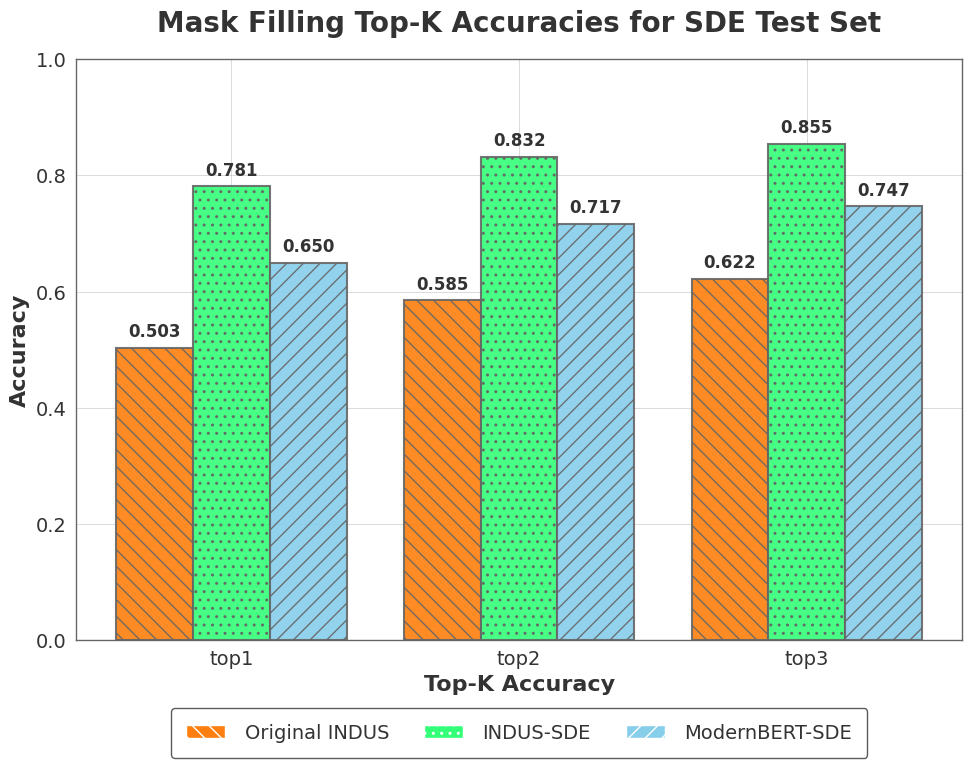

In [19]:
def plot_masking_accuracy(
    masking_accuracies,
    model_configs,
    save_path=None,
    figsize=(14, 8),
    dpi=600,
    legend_cols=3
):
    """
    Create masking accuracy bar plot using existing data structures
    
    Args:
        masking_accuracies (dict): Data structure with model accuracies
        model_configs (dict): Model configuration with colors and hatch patterns
        save_path (str): Path to save the plot
        figsize (tuple): Figure size (width, height)
        dpi (int): Plot resolution
        legend_cols (int): Number of legend columns
    """
    
    # Set up dark theme to match your existing plots
    sns.set_style("darkgrid", {
        'grid.alpha': 0.4,
        'axes.facecolor': 'none',
        'figure.facecolor': 'none'
    })
    
    plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'figure.titlesize': 20,
    'text.color': '#333333',        # Changed to gray for better readability
    'axes.labelcolor': '#333333',   # Changed to gray for better readability
    'xtick.color': '#333333',       # Changed to gray for better readability
    'ytick.color': '#333333',       # Changed to gray for better readability
    'axes.edgecolor': '#333333',    # Changed to gray for softer borders
    'grid.color': 'lightgray',      # Changed to lighter gray
    })
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Extract data for plotting
    top_k_categories = ['top1', 'top2', 'top3']
    model_names = list(masking_accuracies.keys())
    
    # Set up bar positions
    n_groups = len(top_k_categories)
    n_models = len(model_names)
    bar_width = 0.8 / n_models
    r = np.arange(n_groups)
    
    # Create bars for each model
    bars_list = []
    for i, model_name in enumerate(model_names):
        model_data = masking_accuracies[model_name]['data']
        model_config = model_configs[model_name]
        values = [model_data[k] for k in top_k_categories]
        
        # Calculate bar positions
        bar_positions = r + i * bar_width - (n_models - 1) * bar_width / 2
        
        # Create bars
        bars = ax.bar(
            bar_positions,
            values,
            bar_width,
            label=model_name,
            color=model_config['color'],
            hatch=model_config['hatch'],
            edgecolor='#666666',  # Changed to gray
            linewidth=1.5,
            alpha=0.9
        )
        bars_list.extend(bars)
        
        # Add value annotations
        for j, (pos, val) in enumerate(zip(bar_positions, values)):
            ax.annotate(
                f"{val:.3f}",
                (pos, val),
                ha='center',
                va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=12,
                fontweight='bold',
                color='#333333'  # Changed to gray
            )
    
    # Customize axes
    ax.set_xlabel('Top-K Accuracy', fontsize=16, color='#333333', fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=16, color='#333333', fontweight='bold')
    ax.set_title('Mask Filling Top-K Accuracies for SDE Test Set', fontsize=20, color='#333333', fontweight='bold', pad=20)
    
    # Set x-axis
    ax.set_xticks(r)
    ax.set_xticklabels(top_k_categories)
    
    # Style axes to match your existing plots
    ax.patch.set_facecolor('none')
    ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='gray')
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax.tick_params(axis='both', which='major', labelsize=14, colors='#333333')
    
    # Enhanced spine styling to match GKR plot
    for spine in ax.spines.values():
        spine.set_color('#666666')  # Changed to gray
        spine.set_linewidth(1.0)
    
    # Create custom legend
    legend_handles = []
    for model_name in model_names:
        model_config = model_configs[model_name]
        handle = Patch(
            facecolor=model_config['color'],
            hatch=model_config['hatch'],
            label=model_name,
            edgecolor='white',  # Changed to gray
            linewidth=1.0
        )
        legend_handles.append(handle)
    
    # Position legend below plot (matching your other plots)
    legend = ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=legend_cols,
        frameon=True,
        fancybox=True,
        shadow=False,
        fontsize=14,
        columnspacing=1.8,
        handletextpad=1.0,
        borderpad=0.8
    )
    
    # Style legend frame to match your other plots
    legend.get_frame().set_facecolor('none')
    legend.get_frame().set_edgecolor('#333333')  # Changed to gray
    legend.get_frame().set_linewidth(1.0)
    
    for text in legend.get_texts():
        text.set_color('#333333')  # Changed to gray
    
    # Set y-axis limits for better visualization
    ax.set_ylim(0, 1.0)
    
    # Final styling
    fig.patch.set_facecolor('none')  # Transparent background
    plt.tight_layout()
    
    print("Masking accuracy plot created successfully!")
    
    # Save plot with transparent background
    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight',
            facecolor='none',
            edgecolor='none',
            transparent=True,
            pad_inches=0.1
        )
        print(f"Masking accuracy plot saved to: {save_path}")
    
    return fig

# Create the plot using your existing data structures
fig = plot_masking_accuracy(
    masking_accuracies=masking_accuracies,
    model_configs=model_configs,
    save_path='masking_accuracy_plot.png',
    figsize=(10, 8),
    legend_cols=3
)

plt.show()

# for tdaamm

Threshold vs Precision plot created successfully!
Plot saved to: threshold_precision_plot.png


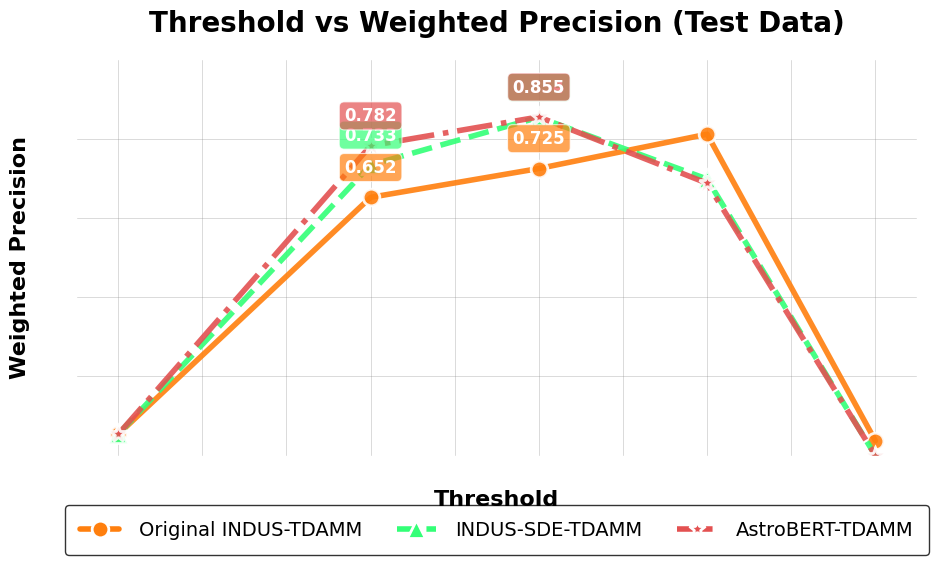

In [11]:
# Create dictionary from the table data
threshold_precision_data = {
    "original-indus": {
        "thresholds": [0.0, 0.3, 0.5, 0.7, 0.9],
        "precision": [0.0538, 0.6517, 0.7245, 0.8111, 0.0373]
    },
    "indus-sde-v0.2": {
        "thresholds": [0.0, 0.3, 0.5, 0.7, 0.9],
        "precision": [0.0538, 0.7334, 0.8537, 0.6978, 0.0000]
    },
    "astrobert": {
        "thresholds": [0.0, 0.3, 0.5, 0.7, 0.9],
        "precision": [0.0538, 0.7820, 0.8547, 0.6873, 0.0000]
    }
}

# Model styling configuration
threshold_model_configs = {
    "original-indus": {
        "color": "#ff7f0e",
        "marker": "o",
        "linestyle": "-",
        "markersize": 8,
        "display_name": "Original INDUS-TDAMM"
    },
    "indus-sde-v0.2": {
        "color": "#33ff77",
        "marker": "^",
        "linestyle": "--",
        "markersize": 9,
        "display_name": "INDUS-SDE-TDAMM"
    },
    "astrobert": {
        "color": "#E35151",
        "marker": "*",
        "linestyle": "-.",
        "markersize": 8,
        "display_name": "AstroBERT-TDAMM"
    }
}

def plot_threshold_precision(
    data_dict,
    model_configs,
    save_path=None,
    figsize=(12, 8),
    dpi=600,
    legend_cols=3,
    annotation_thresholds=[0.3, 0.5, 0.7]
):
    """
    Create threshold vs weighted precision line plot
    
    Args:
        data_dict (dict): Dictionary with model data
        model_configs (dict): Model styling configurations
        save_path (str): Path to save the plot
        figsize (tuple): Figure size (width, height)
        dpi (int): Plot resolution
        legend_cols (int): Number of legend columns
        annotation_thresholds (list): Thresholds to annotate
    """
    
    # Set up styling
    sns.set_style("darkgrid", {
        'grid.alpha': 0.4,
        'axes.facecolor': 'none',
        'figure.facecolor': 'none'
    })
    
    plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'figure.titlesize': 20,
    'text.color': 'black',        # Changed from 'white' to 'black'
    'axes.labelcolor': 'black',   # Changed from 'white' to 'black'
    'xtick.color': 'black',       # Changed from 'white' to 'black'
    'ytick.color': 'black',       # Changed from 'white' to 'black'
    'axes.edgecolor': 'black',    # Changed from 'white' to 'black'
        'grid.color': 'gray',         # Changed from 'white' to 'gray'
    })
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot lines for each model
    for model_name, model_data in data_dict.items():
        config = model_configs[model_name]
        
        # Plot line with markers
        ax.plot(
            model_data['thresholds'],
            model_data['precision'],
            color=config['color'],
            marker=config['marker'],
            linestyle=config['linestyle'],
            linewidth=4.0,
            markersize=config['markersize'] + 4,
            markeredgecolor='white',
            markeredgewidth=2.0,
            label=config['display_name'],
            alpha=0.9
        )
        
        # Add value annotations at selected thresholds
        for thresh, prec in zip(model_data['thresholds'], model_data['precision']):
            if thresh in annotation_thresholds:
                ax.annotate(
                    f"{prec:.3f}",
                    (thresh, prec),
                    xytext=(0, 15),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=12,
                    color='white',
                    fontweight='bold',
                    bbox=dict(
                        boxstyle='round,pad=0.3',
                        facecolor=config['color'],
                        alpha=0.7,
                        edgecolor='white',
                        linewidth=0.8
                    )
                )
    
    # Customize axes
    ax.set_xlabel('Threshold', fontsize=16, color='black', fontweight='bold')
    ax.set_ylabel('Weighted Precision', fontsize=16, color='black', fontweight='bold')
    ax.set_title('Threshold vs Weighted Precision (Test Data)', fontsize=20, color='black', fontweight='bold', pad=20)
    
    # Style axes
    ax.patch.set_facecolor('none')
    ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='gray')
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='major', labelsize=14, colors='white', labelcolor='white')
    
    # Set axis ranges
    ax.set_xlim(-0.05, 0.95)
    ax.set_ylim(0, 1.0)
    
    # Set x-axis ticks to match the thresholds
    ax.set_xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
    ax.set_xticklabels(['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9'])
    
    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_linewidth(1.0)
    
    # Create custom legend
    legend_handles = []
    for model_name in data_dict.keys():
        config = model_configs[model_name]
        from matplotlib.lines import Line2D
        handle = Line2D(
            [0], [0],
            color=config['color'],
            marker=config['marker'],
            linestyle=config['linestyle'],
            linewidth=4.0,
            markersize=config['markersize'] + 4,
            markeredgecolor='white',
            markeredgewidth=2.0,
            label=config['display_name']
        )
        legend_handles.append(handle)
    
    legend = ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=legend_cols,
        frameon=True,
        fancybox=True,
        shadow=False,
        fontsize=14,
        columnspacing=1.8,
        handletextpad=1.0,
        borderpad=0.8
    )
    
    # Style legend
    legend.get_frame().set_facecolor('none')
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1.0)
    
    for text in legend.get_texts():
        text.set_color('black')
    
    # Final styling
    fig.patch.set_facecolor('none')
    plt.tight_layout()
    
    print("Threshold vs Precision plot created successfully!")
    
    # Save plot
    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight',
            facecolor='none',
            edgecolor='none',
            transparent=True,
            pad_inches=0.1
        )
        print(f"Plot saved to: {save_path}")
    
    return fig

# Create the plot
fig = plot_threshold_precision(
    data_dict=threshold_precision_data,
    model_configs=threshold_model_configs,
    save_path='threshold_precision_plot.png',
    figsize=(10, 6),
    legend_cols=3,
    annotation_thresholds=[0.3, 0.5]
)

plt.show()